# 机器学习案例：高血压预测模型

### 知识点简述
本案例主要涉及**监督学习中的二分类问题**。通过收集患者的年龄、性别、胸痛类型、血压、胆固醇等身体指标，利用机器学习算法（如逻辑回归、K近邻）构建预测模型，判断患者是否患有高血压。

### 设计程序的意义
1. **辅助诊断**：通过自动化分析身体指标，为医生提供量化的诊断参考。
2. **预防医疗**：早期识别高风险人群，从而进行及时的干预和治疗，降低并发症风险。
3. **数据驱动**：展示如何通过数据处理、可视化分析到模型训练的完整数据科学工作流。

## 一、环境准备
导入分析过程中需要的 Python 库。我们将使用 `pandas` 进行数据处理，`seaborn` 和 `matplotlib` 进行可视化，以及 `sklearn` 和 `xgboost` 进行建模。

In [1]:
###导入我们机器学习需要的package  主要是基础包
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['KaiTi']  #中文
plt.rcParams['axes.unicode_minus'] = False   #负号

## 二、数据加载
从本地 CSV 文件中读取高血压相关的医疗数据，并进行初步查看。

In [2]:
### 读取高血压数据集
data = pd.read_csv('hypertension_data.csv')
# 输出数据的基本规模
print(f"该数据集包含 {data.shape[0]} 条记录，每条记录有 {data.shape[1]} 个维度。")
data.head()

该数据集包含 26083 条记录，每条记录有 14 个维度。


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,57.0,1.0,3,145,233,1,0,150,0,2.3,0,0,1,1
1,64.0,0.0,2,130,250,0,1,187,0,3.5,0,0,2,1
2,52.0,1.0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56.0,0.0,1,120,236,0,1,178,0,0.8,2,0,2,1
4,66.0,0.0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
##使用head查看数据 在此查看数据前6行
data.head(6)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,57.0,1.0,3,145,233,1,0,150,0,2.3,0,0,1,1
1,64.0,0.0,2,130,250,0,1,187,0,3.5,0,0,2,1
2,52.0,1.0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56.0,0.0,1,120,236,0,1,178,0,0.8,2,0,2,1
4,66.0,0.0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,51.0,1.0,0,140,192,0,1,148,0,0.4,1,0,1,1


In [4]:
# 可以看到数据集的部分情况展示，我们的响应变量为target，其他都是特征

In [5]:
##查看列名称
data.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## 三、变量含义说明
在进行深度分析前，我们需要明确每个字段所代表的临床意义。

| 变量名称 | 中文含义 | 变量类别 | 详细解释 |
| :--- | :--- | :--- | :--- |
| age | 年龄 | 数值型 | 患者的年龄 |
| sex | 性别 | 分类型 | 0: 女性, 1: 男性 |
| cp | 胸痛类型 | 分类型 | 0: 典型心绞痛, 1: 非典型心绞痛, 2: 非心绞痛, 3: 无症状 |
| trestbps | 静息血压 | 数值型 | 入院时的静息血压 (mm Hg) |
| chol | 胆固醇 | 数值型 | 血清胆固醇 (mg/dl) |
| fbs | 空腹血糖 | 分类型 | > 120 mg/dl (1 = true; 0 = false) |
| restecg | 心电图结果 | 分类型 | 0: 正常, 1: 有ST-T波异常, 2: 显示左心室肥厚 |
| thalach | 最大心率 | 数值型 | 达到的最大心率 |
| exang | 运动诱发心绞痛 | 分类型 | 1 = yes; 0 = no |
| oldpeak | ST段压低值 | 数值型 | 运动相对于休息引起的ST段压低值 |
| slope | ST段坡度 | 分类型 | 运动高峰ST段的坡度 |
| ca | 血管数目 | 数值型 | 荧光透视下的主要血管数目 (0-3) |
| thal | 缺陷类型 | 分类型 | 1: 正常, 2: 固定缺陷, 3: 可逆缺陷 |
| **target** | **诊断结果** | 分类型 | **0: 无高血压, 1: 患有高血压** |

In [6]:
###随后查看一下整体数据情况
data.shape

(26083, 14)

In [7]:
###结果发现数据量为26000+，特征为13个，故满足我们的数据集要求

In [8]:
####随后对数据集进行一些描述性统计分析，通过describe函数来进行
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,26083.000000,26058.00000,26083.000000,26083.000000,26083.000000,26083.000000,26083.000000,26083.000000,26083.000000,26083.000000,26083.000000,26083.000000,26083.000000,26083.000000
mean,55.661389,0.50000,0.958594,131.592992,246.246061,0.149753,0.526512,149.655024,0.326573,1.039512,1.400299,0.721849,2.318752,0.547253
std,15.189768,0.50001,1.023931,17.588809,51.643522,0.356836,0.525641,22.858109,0.468969,1.165138,0.616513,1.011608,0.604659,0.497772
min,11.000000,0.00000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,44.000000,0.00000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,0.50000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,67.000000,1.00000,2.000000,140.000000,275.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,98.000000,1.00000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


从describe函数结果来看，可以对每个特征的总数合计，以及展示其均值、标准差、最大最小值。以及分位数

## 四、数据质量评估与预处理
我们需要检查数据中是否存在缺失值（Null）或异常值，以确保模型的鲁棒性。

In [9]:
# 随后用info查看数据集类型
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26083 entries, 0 to 26082
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       26083 non-null  float64
 1   sex       26058 non-null  float64
 2   cp        26083 non-null  int64  
 3   trestbps  26083 non-null  int64  
 4   chol      26083 non-null  int64  
 5   fbs       26083 non-null  int64  
 6   restecg   26083 non-null  int64  
 7   thalach   26083 non-null  int64  
 8   exang     26083 non-null  int64  
 9   oldpeak   26083 non-null  float64
 10  slope     26083 non-null  int64  
 11  ca        26083 non-null  int64  
 12  thal      26083 non-null  int64  
 13  target    26083 non-null  int64  
dtypes: float64(3), int64(11)
memory usage: 2.8 MB


通过检查发现 `sex` 字段存在少量缺失值。这里我们采用**前向填充（Forward Fill）**的方法进行处理。在前向填充中，缺失值将由其上一个非缺失值填充，这在某些有序或随机分布的数据中是常用的简单处理方式。

In [10]:
# 使用前向填充处理缺失值
data.fillna(method='ffill', inplace=True) 

# 再次检查缺失值情况，确认处理结果
missing_after = data.isnull().sum().sum()
print(f"处理后全表缺失值总数: {missing_after}")

处理后全表缺失值总数: 0


C:\Users\86131\AppData\Local\Temp\ipykernel_35204\683442977.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill', inplace=True)


发现性别有空值 后续处理  向前填充

## 五、探索性数据分析 (EDA)
通过可视化手段探索特征与目标变量（高血压）之间的关系。

### 5.1 性别与胸痛类型对发病率的影响
我们分析不同性别和不同胸痛程度下的高血压平均比例。

In [11]:
data.fillna(method='ffill',inplace=True) 

C:\Users\86131\AppData\Local\Temp\ipykernel_35204\2426530593.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data.fillna(method='ffill',inplace=True)


In [12]:
###再次查看
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [13]:
#查看一下重复值  
data.duplicated().sum()

np.int64(17)

发现数据集还是挺完善的，可以直接拿过来用

<Axes: >

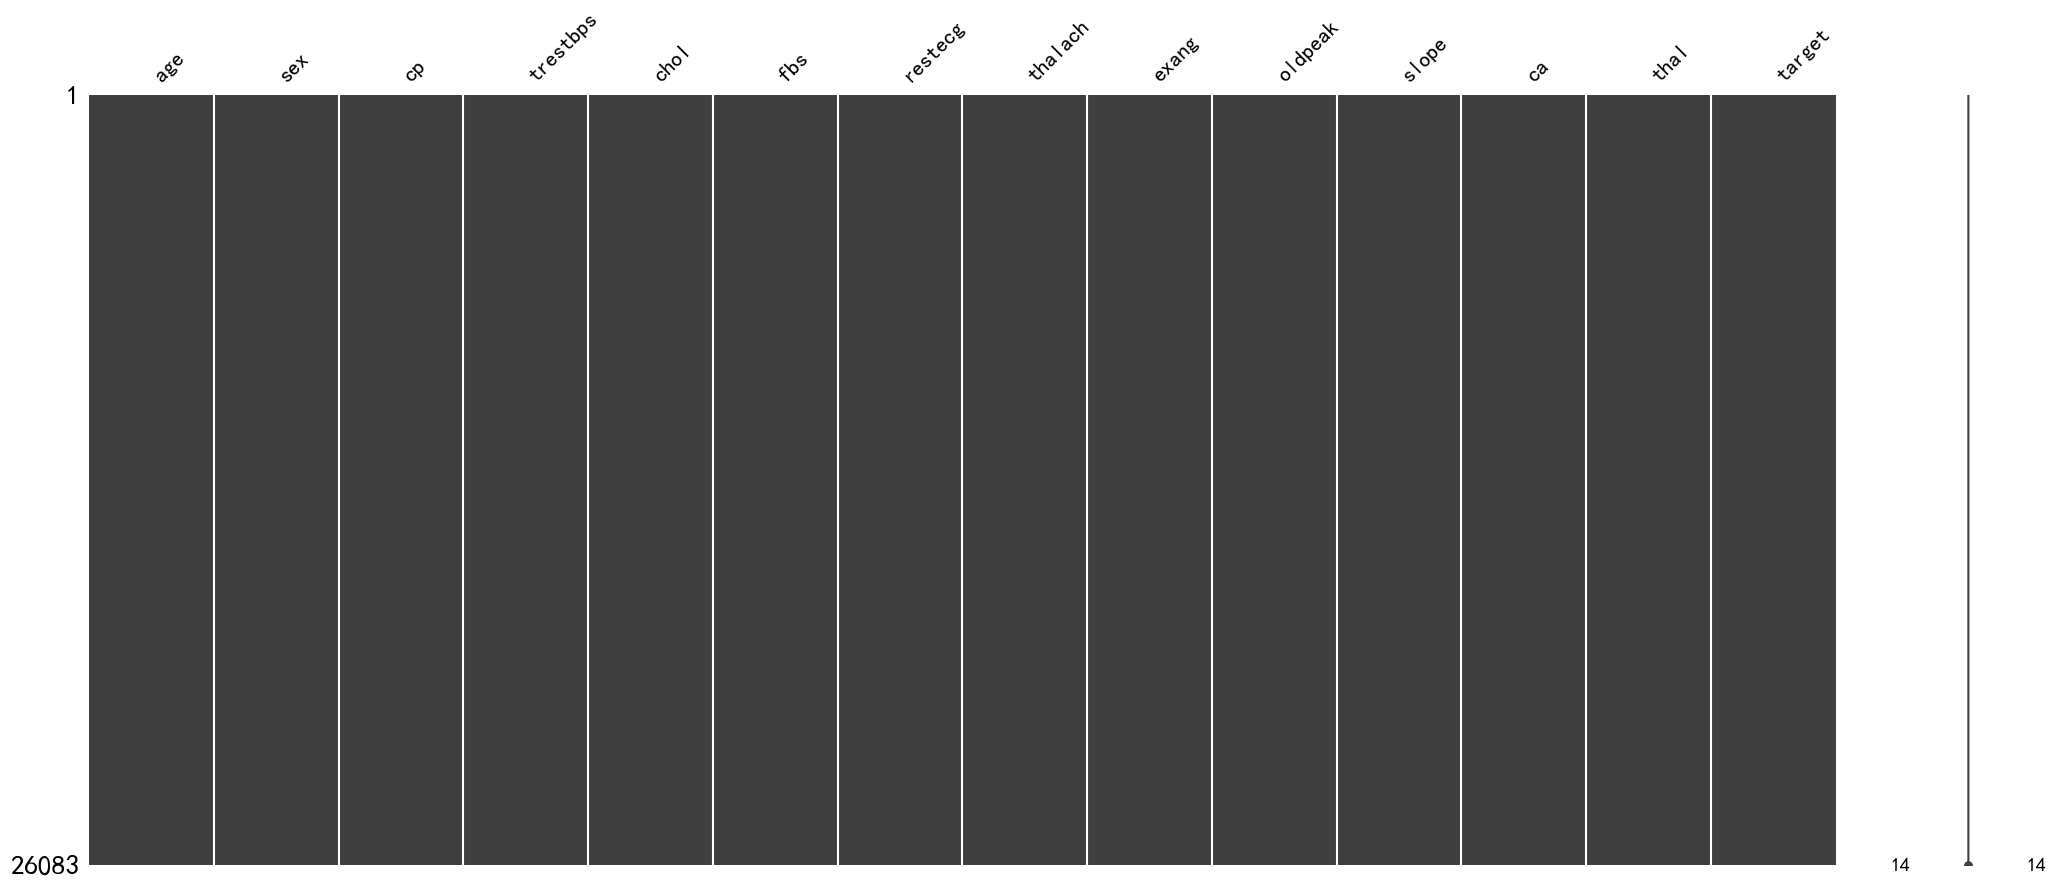

In [14]:
####可视化
import missingno as msno
msno.matrix(data)

In [15]:
###使用groupby函数进行分组查看
# 按年龄和胸痛类型分组，计算是否有高血压
grouped = data.groupby(['sex', 'cp'])['target'].mean().reset_index()

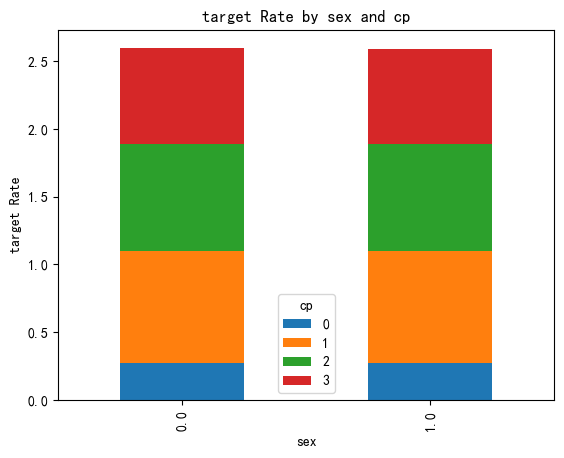

In [16]:
# 显示每个性别和吸烟状态组合的中风发生率
grouped.pivot(index='sex', columns='cp', values='target').plot(kind='bar', stacked=True)
plt.title('target Rate by sex and cp')
plt.xlabel('sex')
plt.ylabel('target Rate')
plt.show()

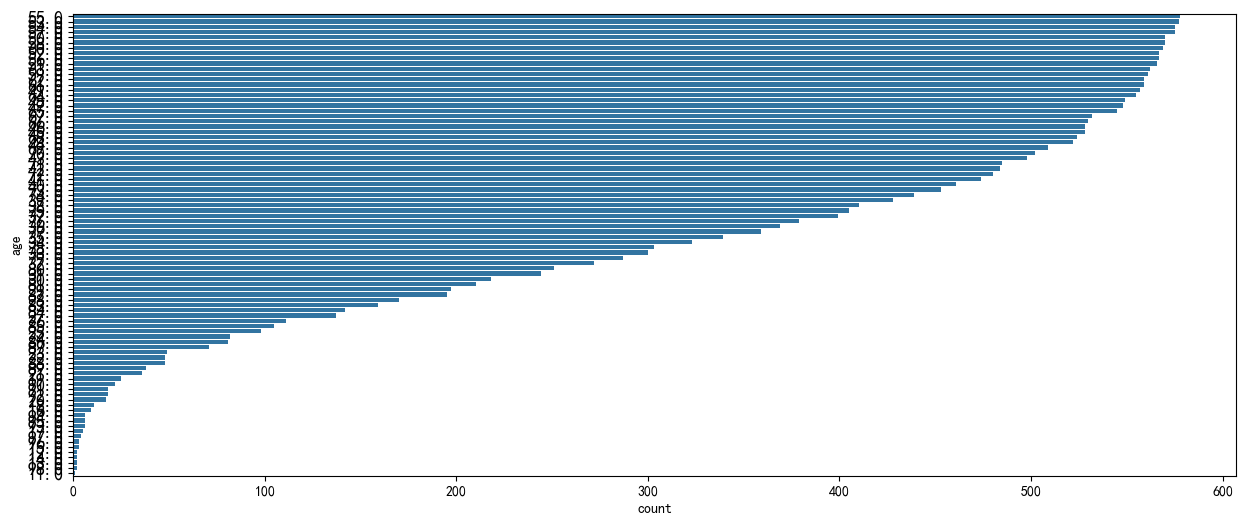

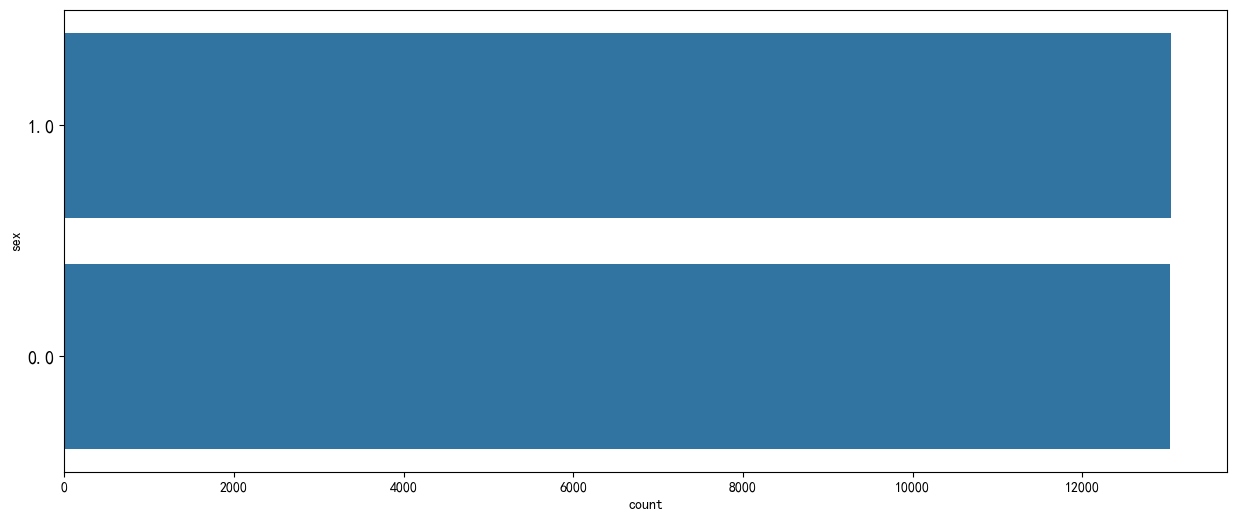

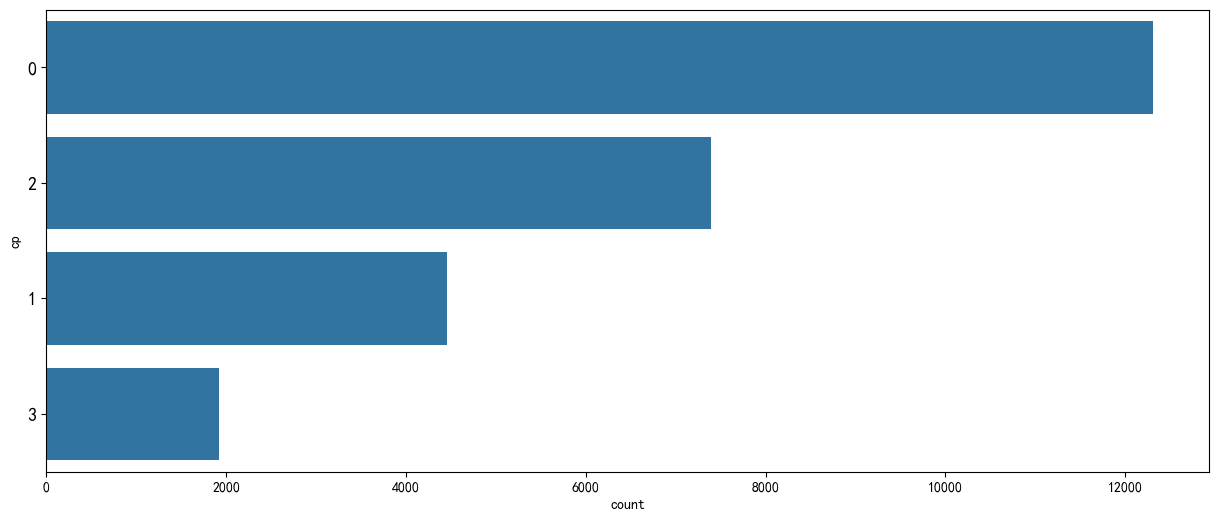

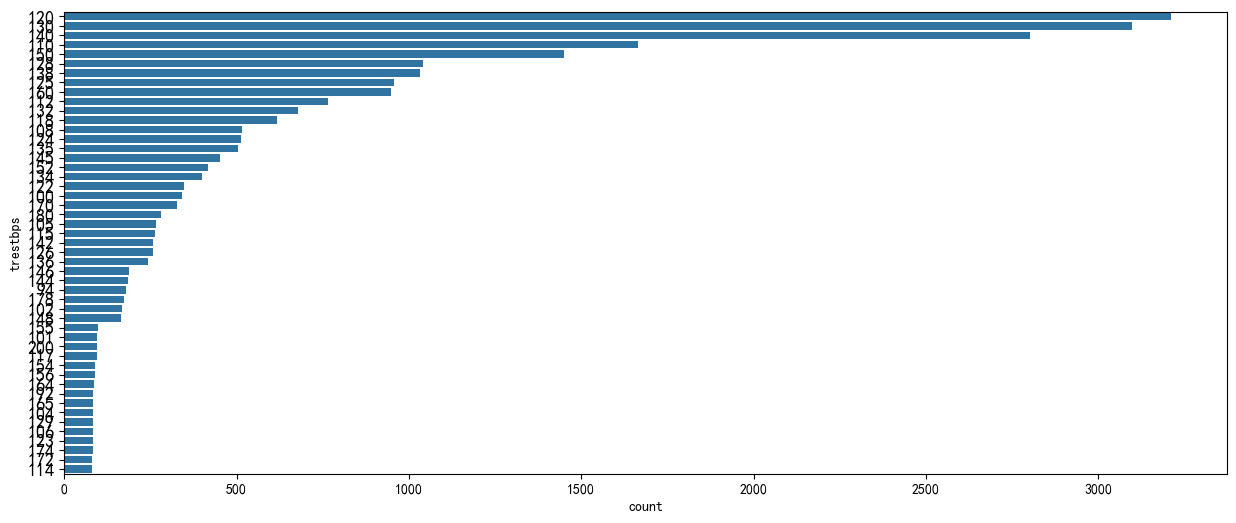

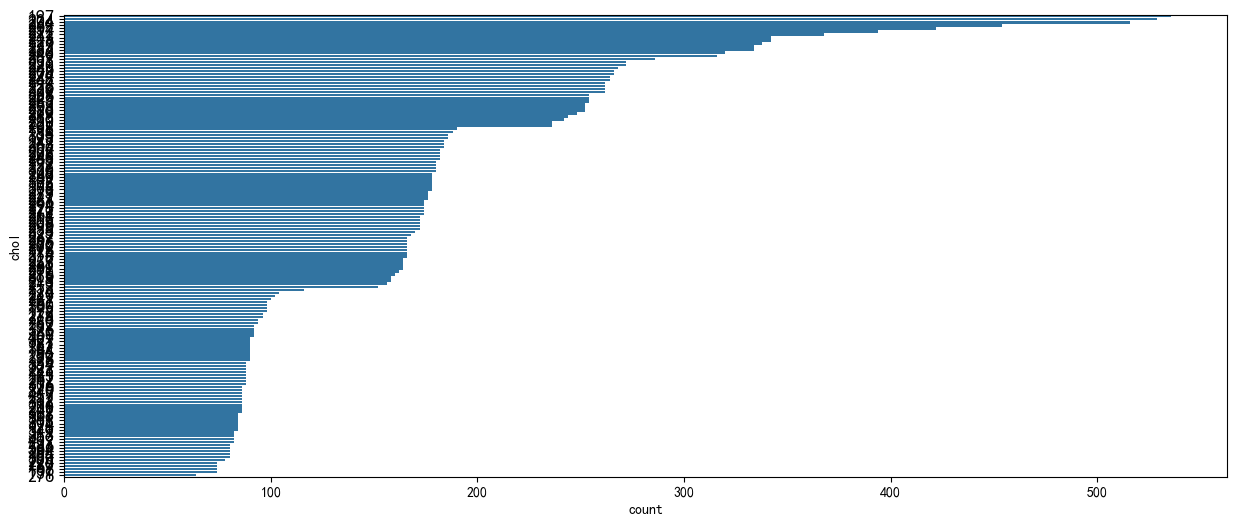

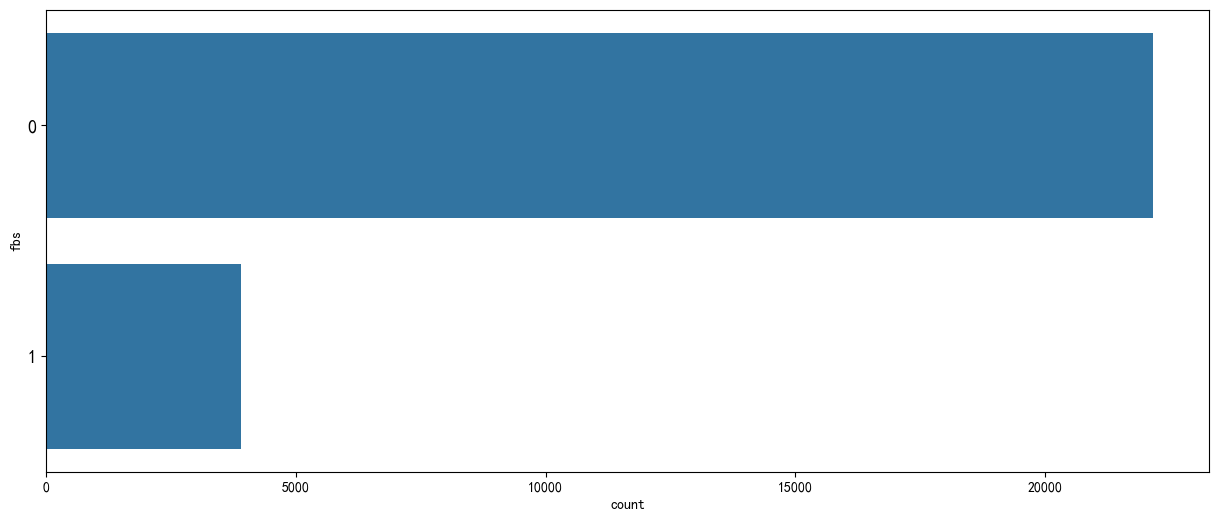

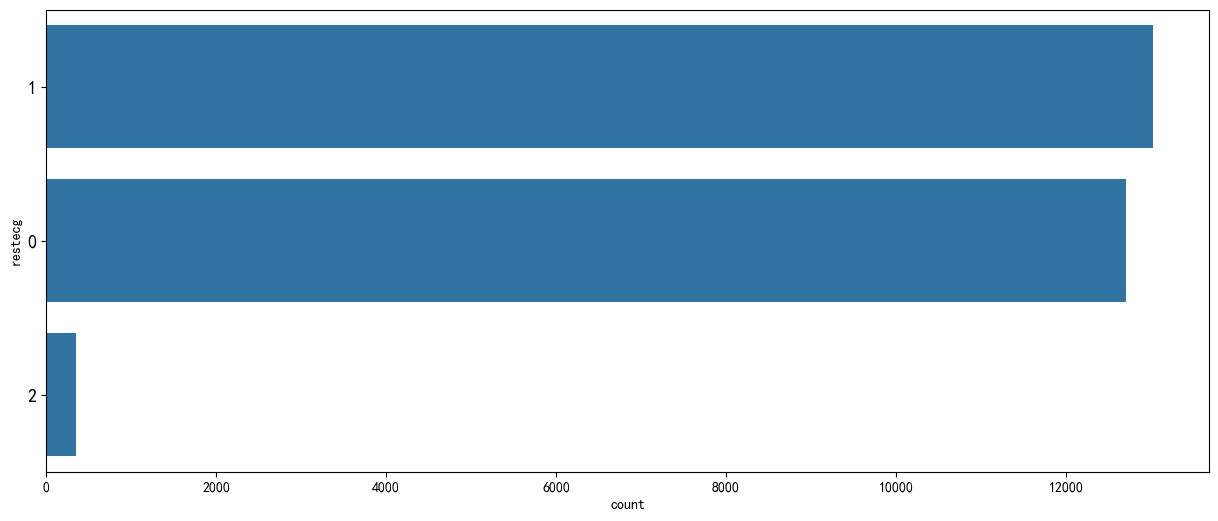

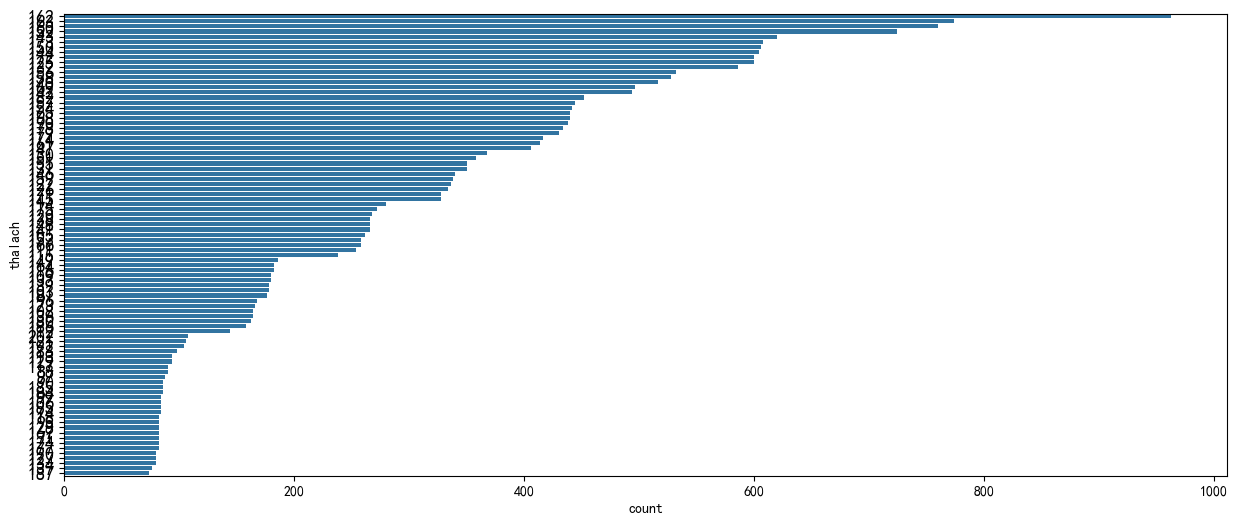

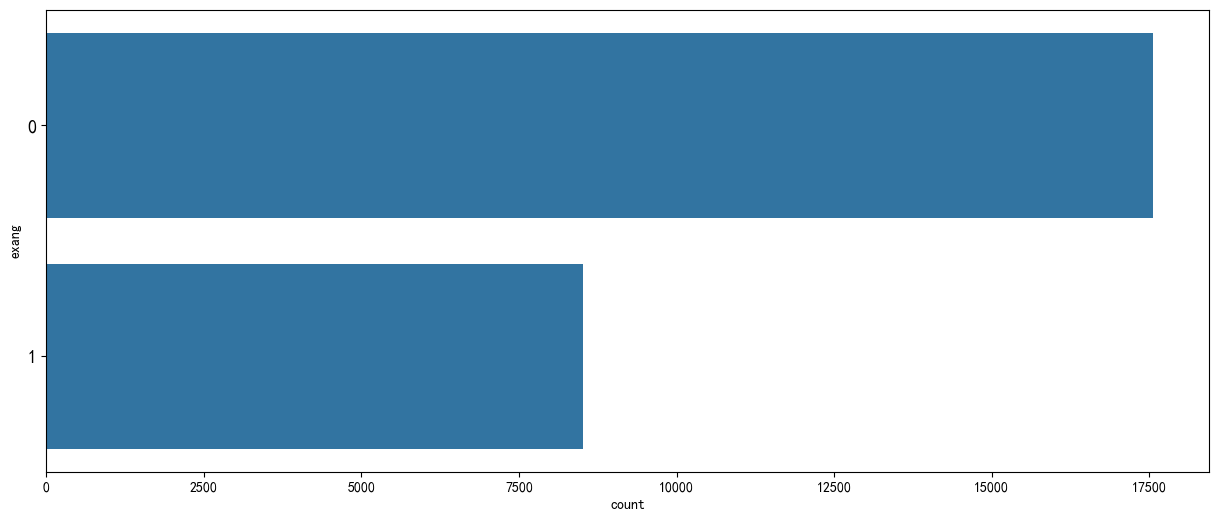

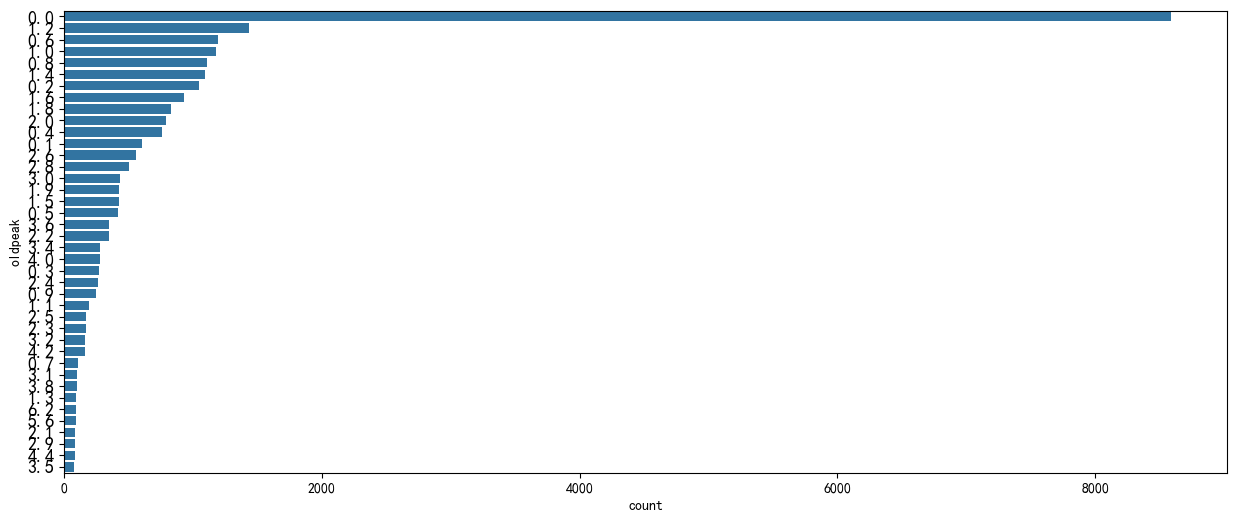

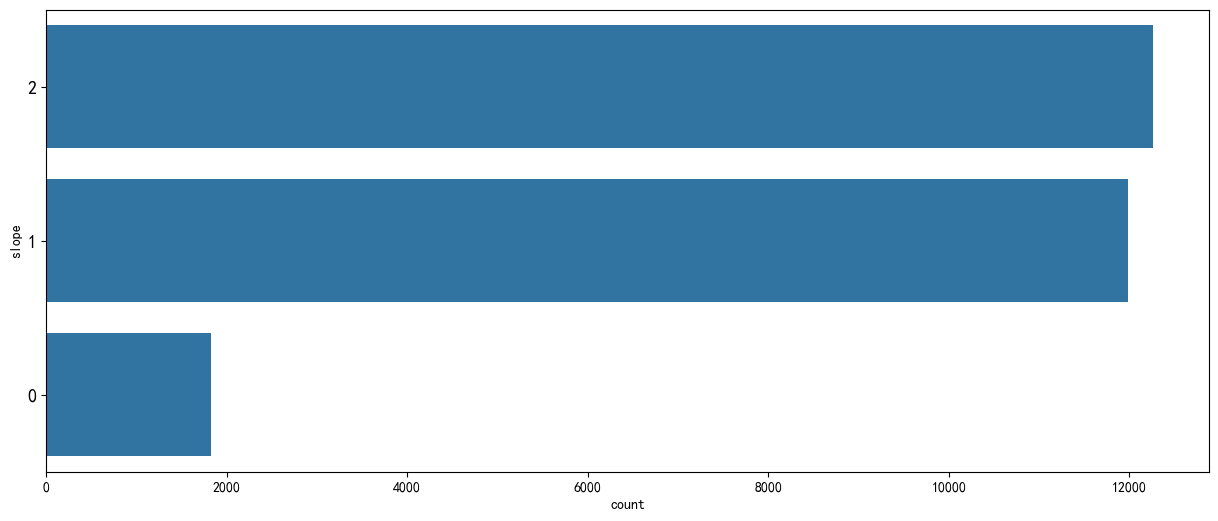

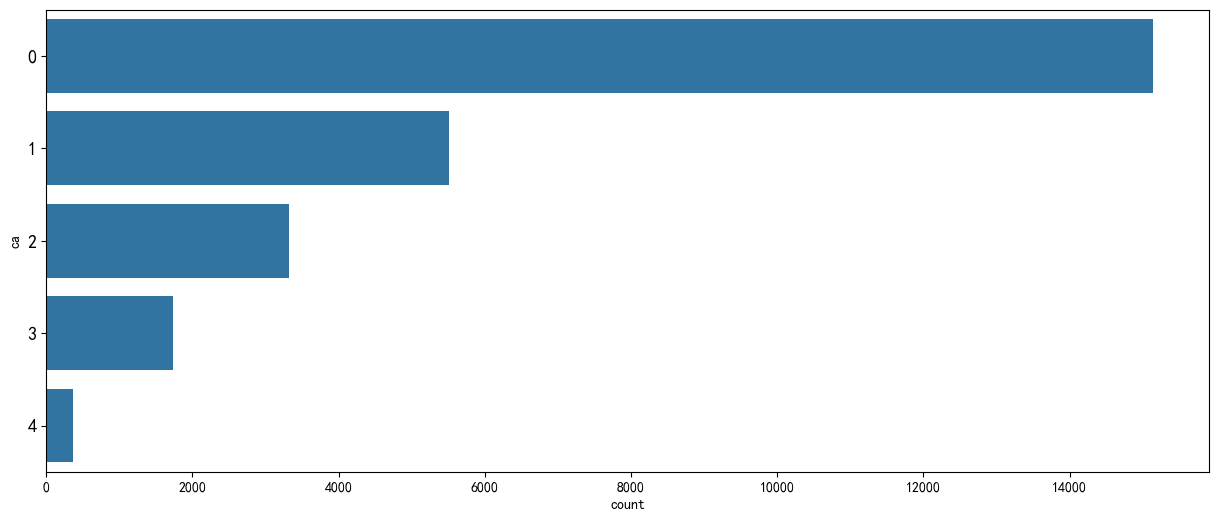

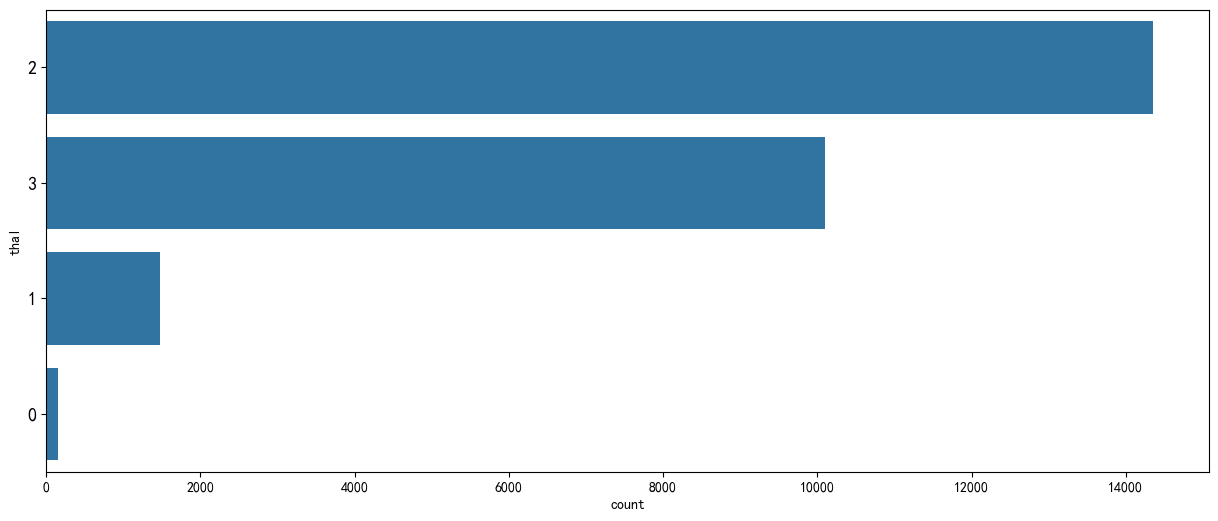

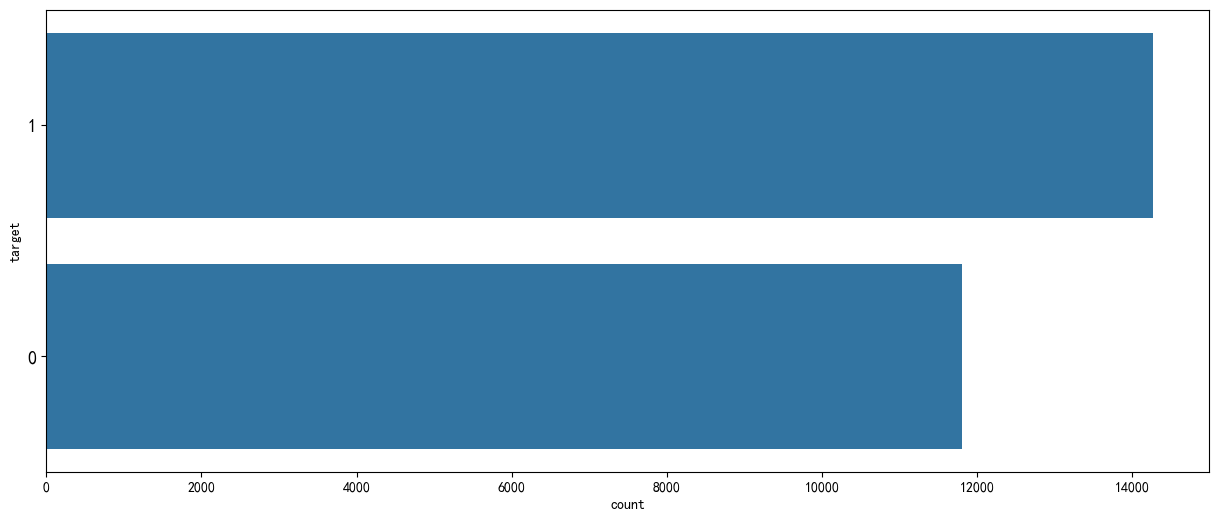

In [17]:
###对特征分别进行可视化一下   比如各个特征的占比情况等等
import seaborn as sb
for i in data.columns:
    fig, ax = plt.subplots(1,1, figsize=(15, 6))
    sb.countplot(y = data[i],data=data, order=data[i].value_counts().index)
    plt.ylabel(i)
    plt.yticks(fontsize=13)
    plt.show()

差不多每个变量都可视化出来了，但是其中有一些数值比较大的数据可能看的不是很清楚

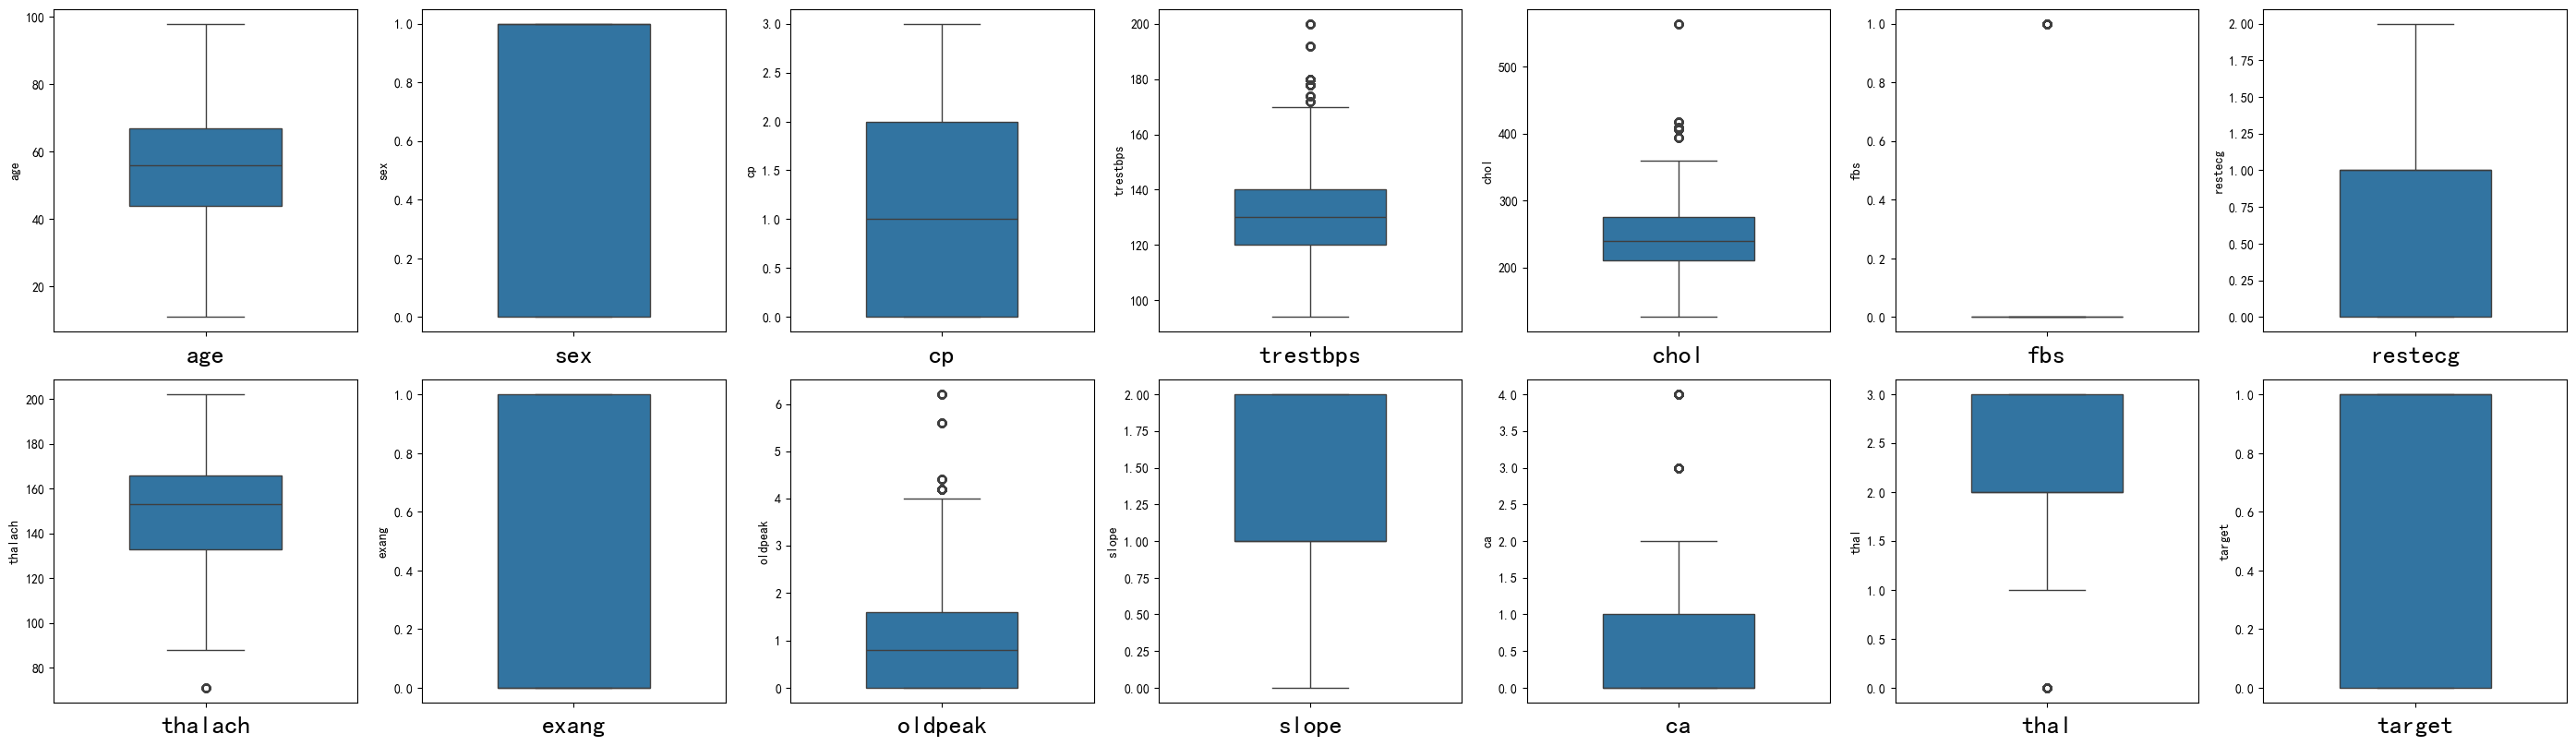

In [18]:
# 我们还要画图查看每个X的分布
#查看特征变量的箱线图分布
columns = data.columns.tolist() # 列表头
dis_cols = 7                   #一行几个
dis_rows = len(columns)
plt.figure(figsize=(4 * dis_cols, 4 * dis_rows))
 
for i in range(len(columns)):
    plt.subplot(dis_rows,dis_cols,i+1)
    sns.boxplot(data=data[columns[i]], orient="v",width=0.5)
    plt.xlabel(columns[i],fontsize = 20)
plt.tight_layout()
#plt.savefig('特征变量箱线图',formate='png',dpi=500)
plt.show()

从箱线图可以看出，大部分变量的分布都是较为合理的，只是个别变量比如trestbps和chol等变量存在一些离群点

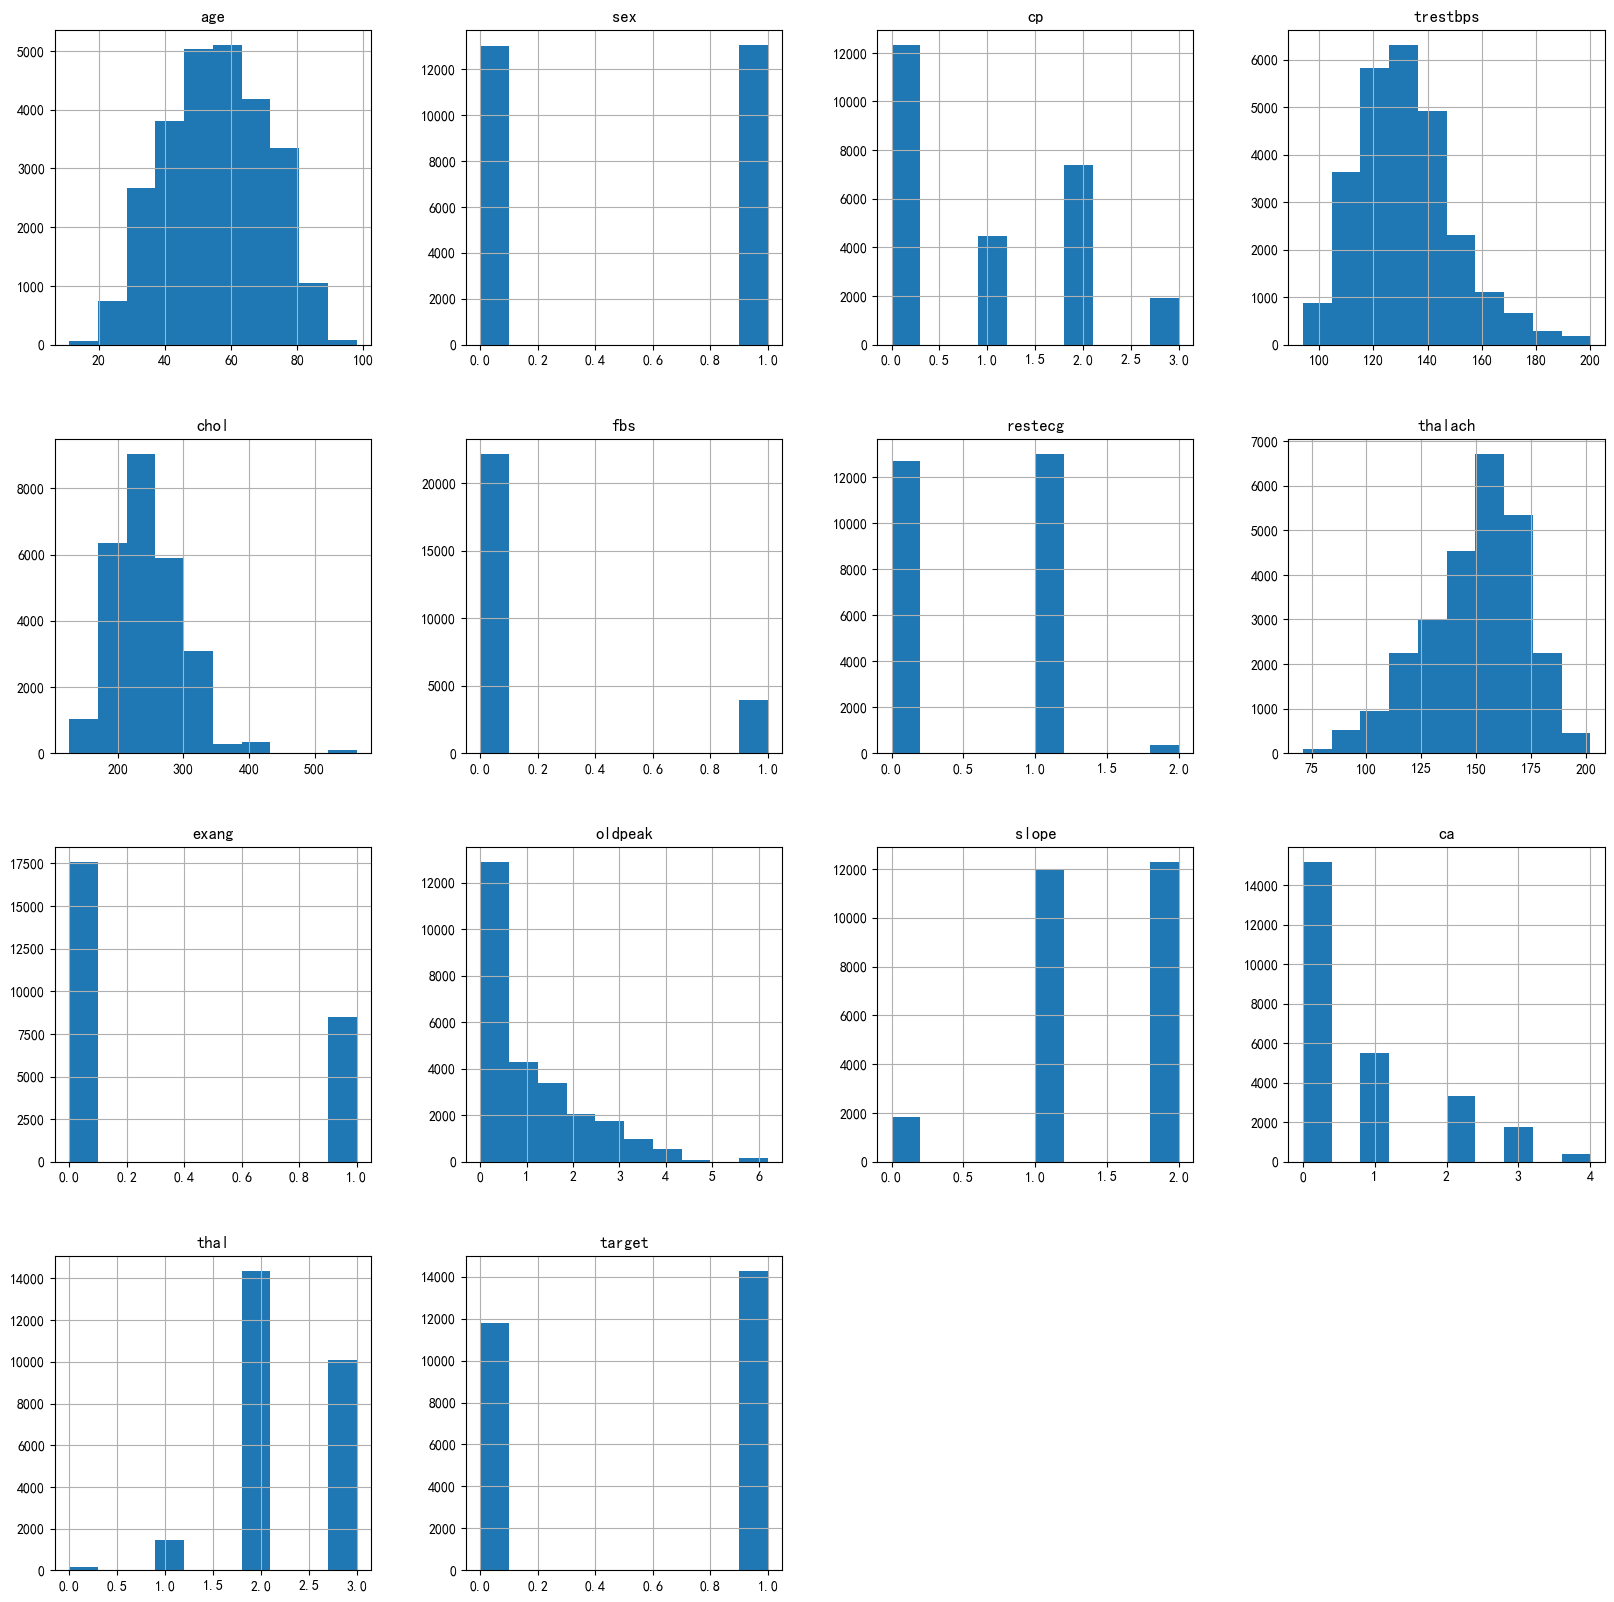

In [19]:
###再画直方图看看
data.hist(figsize=(20,20))
plt.show()

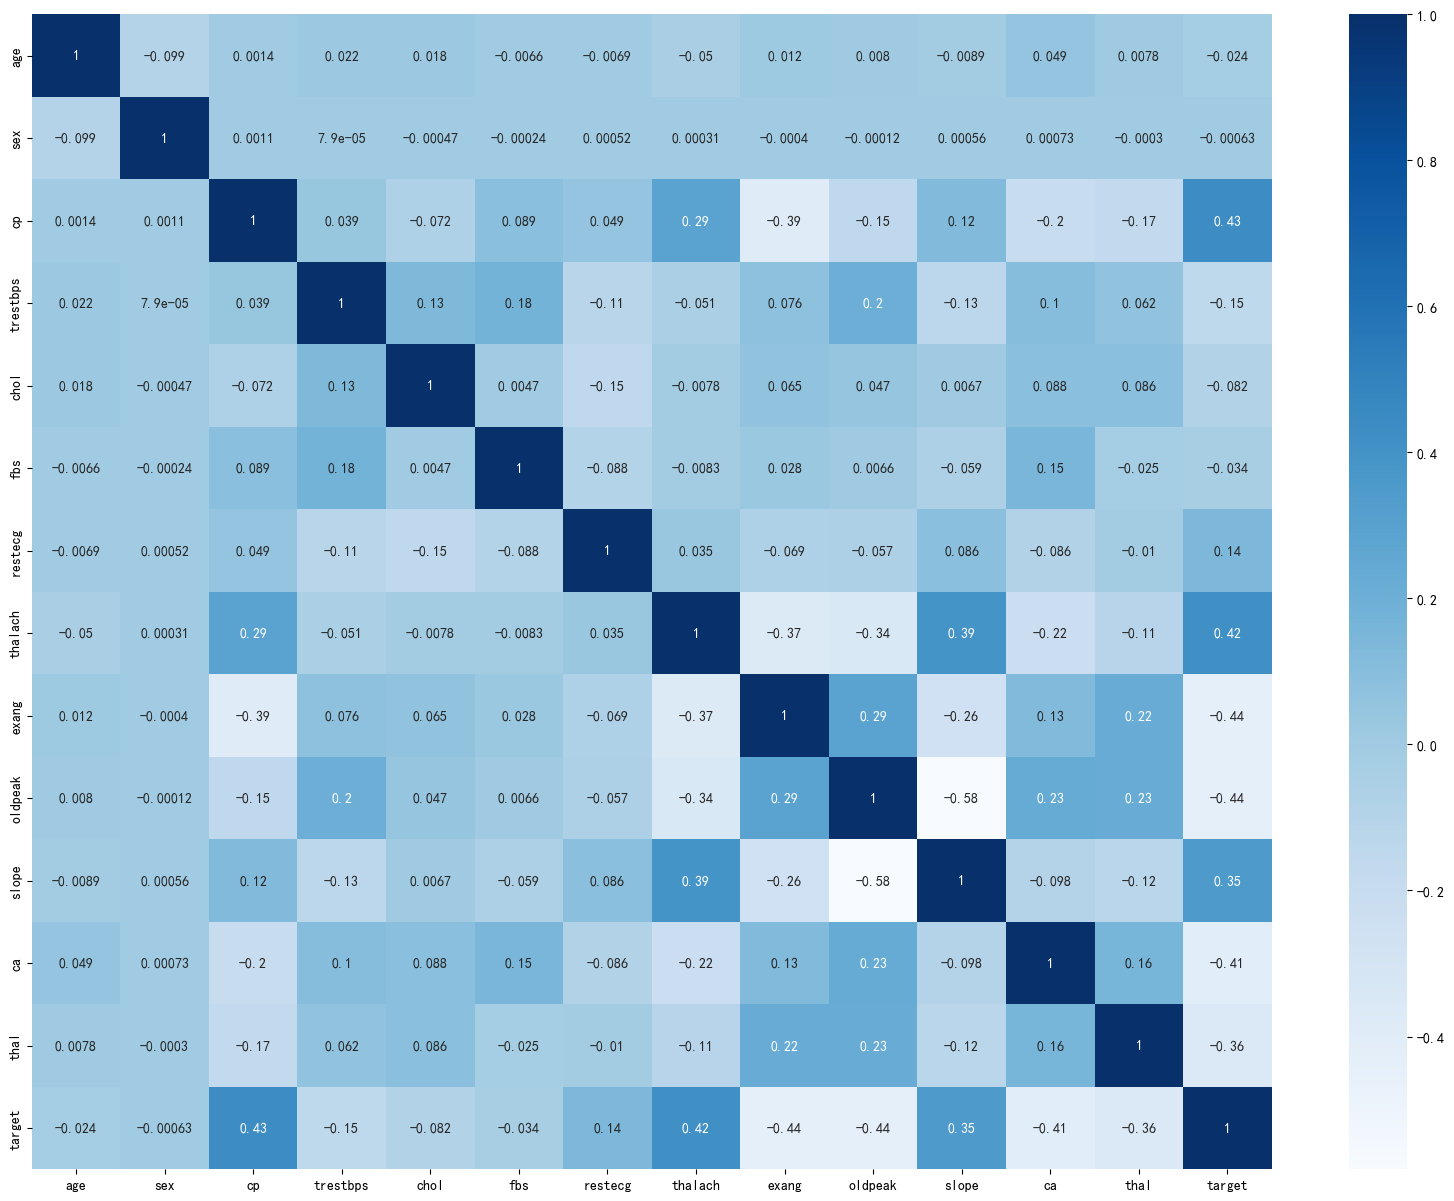

In [20]:
###画出各个特征的热力图
plt.figure(figsize=(20,15))
p=sns.heatmap(data.corr(),annot=True,cmap='Blues')
plt.show()

从上面的结果可以看出，与响应变量较为相关的有cp和thalah以及slope，当然，负相关的我们也要考虑，比如ca和oldpeak和thal等

<Figure size 1200x500 with 0 Axes>

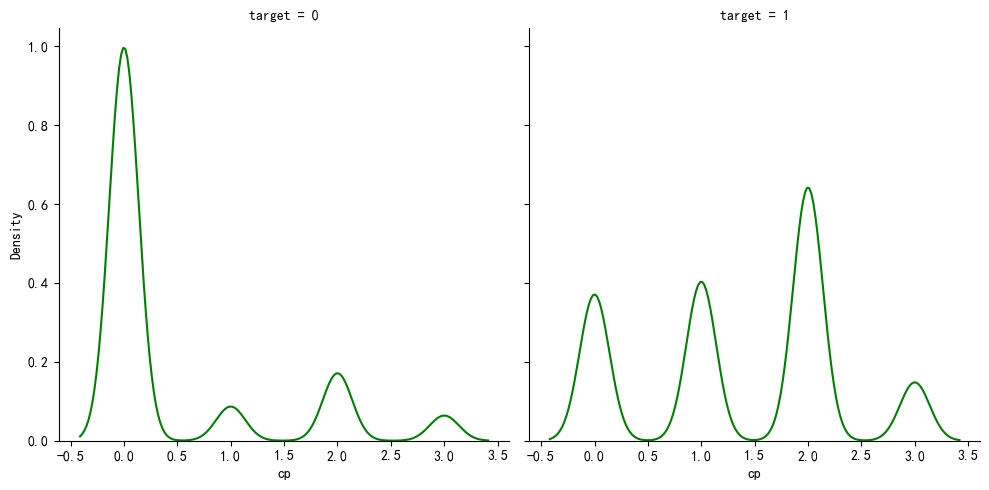

In [21]:
##接下来看一下cp和高血压分布
plt.figure(figsize=(12,5))
sns.displot(x='cp', col='target' , data = data, kind="kde" ,color = 'green');

In [22]:
#接下来
#首先对训练集取出y
y=data['target']
data.drop(['target'],axis=1,inplace=True)

In [23]:
y

0        1
1        1
2        1
3        1
4        1
        ..
26078    0
26079    0
26080    0
26081    0
26082    0
Name: target, Length: 26083, dtype: int64

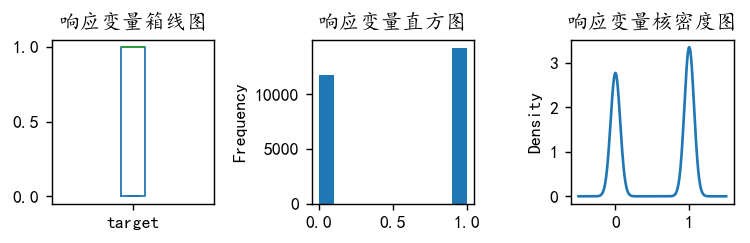

In [24]:
# 然后还需要查看响应变量y的分布
# 查看y的分布
#分类问题
plt.figure(figsize=(6,2),dpi=128)
plt.subplot(1,3,1)
y.plot.box(title='响应变量箱线图')
plt.subplot(1,3,2)
y.plot.hist(title='响应变量直方图')
plt.subplot(1,3,3)
y.plot.kde(title='响应变量核密度图')
#sns.kdeplot(y, color='Red', shade=True)
#plt.savefig('响应变量.png')
plt.tight_layout()
plt.show()

In [25]:
#X异常值处理，先标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_s = scaler.fit_transform(data)

## 六、特征工程与数据划分
在建模之前，我们需要将数据划分为训练集和验证集，并进行**标准化处理**。标准化可以消除不同特征量纲的影响，使模型训练更稳定。

C:\Users\86131\AppData\Local\Temp\ipykernel_35204\2989720607.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(x=X_s,labels=data.columns)


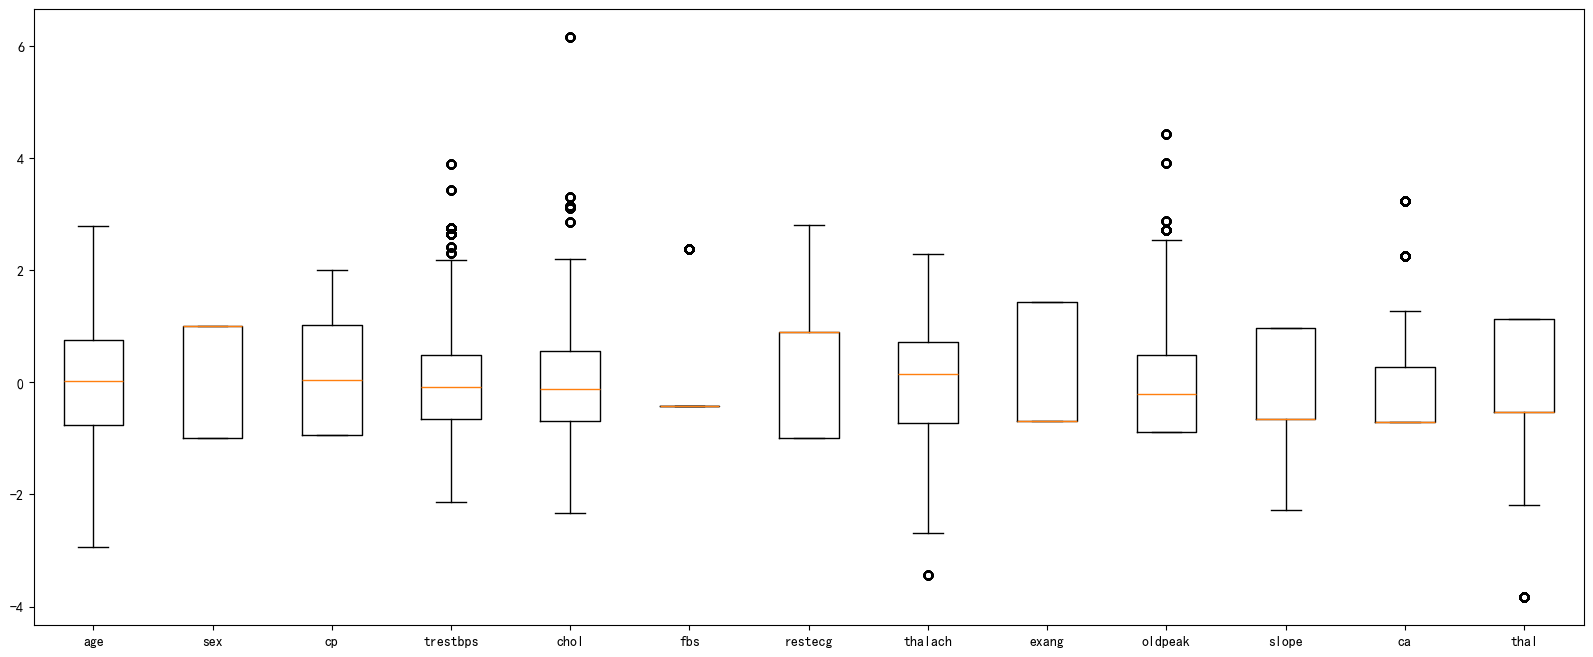

In [26]:
# 然后画图查看
plt.figure(figsize=(20,8))
plt.boxplot(x=X_s,labels=data.columns)
#plt.hlines([-10,10],0,len(columns))
plt.show()

还是存在部分异常值

In [27]:
# def deal_outline(data,col,n):   #数据，要处理的列名，几倍的方差
#     for c in col:
#         mean=data[c].mean()
#         std=data[c].std()
#         return data[(data[c]>mean-n*std)&(data[c]<mean+n*std)]
# 可以使用上面函数调试 但可能影响结果

接下来开始机器学习

In [28]:
#划分训练集和验证集
from sklearn.model_selection import train_test_split
X_train,X_val,y_train,y_val=train_test_split(data,y,test_size=0.2,random_state=0)

## 七、模型构建与对比
我们将对比三种常用的分类算法：**逻辑回归 (Logistic Regression)**、**K近邻 (KNN)** 以及 **XGBoost**。

### 7.1 逻辑回归 (Logistic Regression)
逻辑回归是解决二分类问题的经典线性模型。

In [29]:
# 然后将数据都标准化，再查看形状
#数据标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
print('训练数据形状：')
print(X_train_s.shape,y_train.shape)

训练数据形状：
(20866, 13) (20866,)


In [30]:
###预测模型的画我们选择了 线性回归和KNN
from xgboost.sklearn import XGBClassifier
from sklearn.ensemble import RandomForestRegressor

In [31]:
from sklearn.linear_model import LogisticRegression
model =  LogisticRegression(C=1e10)
model.fit(X_train,y_train )
model.score(X_val,y_val)

d:\anaconda3\envs\AlexNet_ENV\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.8456967605903776

In [32]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=50)
model.fit(X_train,y_train )
model.score(X_val,y_val)

0.9198773241326433

本次实验通过使用机器学习模型，包括线性回归和KNN，结合各项身体指标如年龄、性别、是否胸痛、胆固醇等等，
成功地建立了一个高血压预测模型。这个模型可以有效地预测患者是否患有高血压，对于临床医疗实践具有非常重要的意义。
在预测高血压的过程中，需要进行多个环节的数据预处理、数据可视化、模型选择以及性能评估等步骤，以确保模型的准确性
和可靠性。同时，您还需要考虑如何处理数据缺失或异常等情况，提高模型的鲁棒性和适用性。
总的来说，使用机器学习模型预测高血压的方法能够更加客观地评估患者的病情和疾病风险，
并能够为医生提供更加精准的诊疗建议。这一方法在未来的医疗实践中具有广阔的应用前景。

## 八、拓展与思考

作为教学案例，请同学们思考以下问题并尝试优化模型：

### 1. 评价指标的选择
**思考**：目前我们主要查看的是“准确率 (Accuracy)”，但在医疗预测中，漏掉一个病人（假阴性）的代价可能比误诊一个健康人（假阳性）更大。
*   **拓展任务**：尝试输出并查看“召回率 (Recall)”和“F1-分数”。
*   **解答思路**：使用 `sklearn.metrics` 中的 `classification_report` 或 `confusion_matrix`。如果召回率偏低，可以考虑调整分类阈值（Threshold）。

### 2. 特征重要性
**思考**：在这么多身体指标中，哪一个对预测高血压最关键？
*   **拓展任务**：可视化 XGBoost 模型的特征重要性（Feature Importance）。
*   **解答思路**：调用 `xgb_model.feature_importances_` 并绘制条形图。排名靠前的特征可能就是医学上高血压的关键诱因。

### 3. 数据不平衡问题
**思考**：如果数据集里患病的人非常少，模型可能会倾向于预测所有人都不患病，从而获得虚高的准确率。
*   **拓展任务**：检查原始数据中 `target` 的分布情况。
*   **解答思路**：使用 `data['target'].value_counts()` 查看比例。如果不平衡，可以搜索学习使用 SMOTE 技术进行过采样处理。

### 4. 超参数调优
**思考**：KNN 的 `n_neighbors` 设置为 50 是最优的吗？
*   **拓展任务**：尝试使用交叉验证（Cross-validation）或网格搜索（GridSearch）来寻找最优参数。
*   **解答思路**：学习使用 `sklearn.model_selection.GridSearchCV`。